<a href="https://colab.research.google.com/github/aaqhilahamed2004-ops/QNickel26/blob/main/MvNM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.1 MB/s eta 0:00:00


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace, entropy, Operator

# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
# Architecture (revised, May 2026):
#   - N_BH qubits: black hole register, starts fully occupied
#   - Radiation register: starts EMPTY, grows by 1 qubit per emission step
#   - No separate ENV register — radiation IS the environment
#   - Emitted qubits accumulate memory via collision-model inter-ancilla
#     interactions (Lorenzo, Ciccarello & Palma 2017) and back-act on BH
#   - Global statevector: fixed 2^N_BH dimension throughout (pure state)
#
# Primary observable: S_BH = von Neumann entropy of BH register
#   - Markovian: S(BH) falls due to Hilbert-space shrinking; S(R) monotonic
#   - Non-Markovian: S(BH) shows Page-curve-like recovery; S(R) peaks+falls
#
# Markovian model: numpy density matrix + depolarising Kraus channel (p=1)
#   - Qubit 0 fully decohered each step: information DESTROYED, not transferred
#   - S(radiation) = cumulative entropy emitted = monotonically increasing
#   - This is the GKSL Lindblad limit in discrete time
#
# Page time = N_BH // 2

N_BH = 10         # black hole size (14 exceeds available RAM for statevector)
C_M  = '#1A6FB5'   # Markovian colour
C_NM = '#E06000'   # Non-Markovian colour

print(f"Setup: N_BH={N_BH}, N_RAD_initial=0, Page time ≈ step {N_BH//2}")
print(f"Radiation register grows from 0 to {N_BH} qubits over evaporation.")

Setup: N_BH=10, N_RAD_initial=0, Page time ≈ step 5
Radiation register grows from 0 to 10 qubits over evaporation.


In [26]:
G0_GLOBAL = 1.57

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CIRCUIT BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

def scramble_black_hole(qc, bh):
    """
    Fast-scrambler dynamics on BH register.
    Random layered two-qubit gates implement approximate Haar-random unitary
    (unitary k-design at polynomial depth; Harrow & Low 2009, Brandao et al 2016).
    Models the black hole's own chaotic Hamiltonian evolution.
    Black holes are conjectured to be fastest scramblers in nature (Sekino &
    Susskind 2008): t* ~ log(N_BH).

    Gate angles drawn uniformly from [0, 2π] at each layer — this is
    Haar-random in the sense that each layer samples a different random
    unitary. Uniformity is over the gate angles, not the full unitary group;
    k-design convergence follows from the layered structure (Brandao et al).
    """
    LAYERS = 3
    for _ in range(LAYERS):
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)
        if len(bh) > 1:
            for i in range(len(bh) - 1):
                qc.cx(bh[i], bh[i+1])
                qc.cz(bh[i], bh[i+1])
            for i in range(0, len(bh)-1, 2):
                qc.swap(bh[i], bh[i+1])
            if len(bh) > 3:
                qc.cx(bh[0], bh[-1])
                qc.cy(bh[1], bh[-2])

def radiation_memory_interaction(qc, rad):
   """
    Inter-ancilla collision on the radiation register A = {A_1,...,A_n}.

    Implements nearest-neighbour V_{A_k, A_{k+1}} interactions, realising
    the composite collision model memory term
        sum_k V_{A_k, A_{k+1}}
    from Lorenzo, Ciccarello & Palma (2017), Phys. Rev. A 96, 032107.
    Gate angles drawn uniformly from [0, 2pi].
    This interaction builds correlations among previously emitted qubits,
    breaking CP-divisibility of the BH dynamical map => non-Markovian.
    """
   if len(rad) < 2:
        return
   for i in range(len(rad) - 1):
        qc.cx(rad[i], rad[i+1])
        qc.cz(rad[i+1], rad[i])
        qc.rx(np.random.uniform(0, 2*np.pi), rad[i])
        qc.ry(np.random.uniform(0, 2*np.pi), rad[i+1])
        qc.rz(np.random.uniform(0, 2*np.pi), rad[i])

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# BH-RADIATION BACK-ACTION
# ─────────────────────────────────────────────────────────────────────────────
def bh_radiation_backaction(qc, bh, rad, t=None, N_BH_total=None, g0=G0_GLOBAL):
    """
    BH-radiation back-action channel B -> A_{1..n}.

    Coupling ansatz (phenomenological, not derived):
        g(t) = min( g_0 / (1 - t/N_BH),  pi/2 )
    motivated by the Hawking temperature scaling
        T_H(t) proportional to 1/M(t) = 1/[N_BH (1 - t/N_BH)]
    for a Schwarzschild BH with mass M(t) = N_BH(1 - t/N_BH).
    g_0 is a free parameter; constraint g_0 <= pi/(2 N_BH) ensures
    the pi/2 cap is never active and T_H-scaling holds throughout.
    Cap at pi/2 avoids rotation-gate periodicity artefacts.

    Exponential decay with radiation index i:
        coupling(t, i) = g(t) * exp(-0.3 * (|rad| - 1 - i))
    models weaker back-action from older (more distant) radiation qubits.

    Parameters
    ----------
    t           : emission step index (1-indexed), int
    N_BH_total  : N_BH, total initial BH qubit count, int
    g_0         : base coupling strength, float (default G0_GLOBAL)
    """
    if t is not None and N_BH_total is not None:
        frac = t / N_BH_total
        if frac >= 1.0:
            frac = 1.0 - 1e-6
        hawking_factor = 1.0 / (1.0 - frac)
        base_angle = min(g0 * hawking_factor, np.pi / 2)
    else:
        base_angle = g0

    for b in bh:
        for i, r in enumerate(rad):
            coupling = base_angle * np.exp(-0.3 * (len(rad) - 1 - i))
            qc.cz(b, r)
            qc.cx(r, b)
            qc.rx(coupling, b)
            qc.ry(coupling, r)

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# KRYLOV SPREAD COMPLEXITY
# Trajectory-based Gram-Schmidt adaptation (no Hamiltonian)
# ─────────────────────────────────────────────────────────────────────────────
_krylov_basis = []

def _reset_krylov():
    global _krylov_basis
    _krylov_basis = []

def compute_spread_complexity(state_history):
    """
    Circuit-native Krylov spread complexity.
    Standard spread complexity (Balasubramanian et al 2022) requires a
    Hamiltonian to generate the Krylov basis via Lanczos recursion.
    Since this model is purely gate-based (no explicit Hamiltonian), we adapt:
    the Krylov basis {|b_n>} is built by incremental Gram-Schmidt
    orthogonalisation of the evolved statevector trajectory {|psi(t)>}.
    Spread complexity: K(t) = sum_n n |<b_n|psi(t)>|^2.
    Global statevector is fixed dimension 2^N_BH throughout — inner products
    are always well-defined.
    """
    global _krylov_basis
    for state in state_history[len(_krylov_basis):]:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        for b in _krylov_basis:
            vec -= np.vdot(b, vec) * b
        norm = np.linalg.norm(vec)
        if norm > 1e-10:
            _krylov_basis.append(vec / norm)
    complexities = []
    for state in state_history:
        vec = np.array(state.data, dtype=complex).flatten()
        norm = np.linalg.norm(vec)
        vec = vec / norm if norm > 1e-12 else vec
        k_t = sum(n * abs(np.vdot(b, vec))**2
                  for n, b in enumerate(_krylov_basis))
        complexities.append(k_t)
    return complexities

In [45]:
import numpy as np
from qiskit.quantum_info import DensityMatrix, partial_trace, entropy, Operator, Kraus
from qiskit import QuantumCircuit, QuantumRegister
# from qiskit.circuit.library import DepolarizingChannel # Removed in favor of local Kraus definition

# ─────────────────────────────────────────────────
# MARKOVIAN EVAPORATION — DEPOLARISING KRAUS CHANNEL
# ─────────────────────────────────────────────────
# Physical content of Markovianity:
#   At each step, BH qubit 0 is subjected to a fully depolarising channel
#   (p=1). Kraus operators: { I/sqrt(4), X/sqrt(4), Y/sqrt(4), Z/sqrt(4) }.
#   Net effect: qubit 0 decohered to the maximally mixed state I/2,
#   all entanglement with it destroyed — information is destroyed, not
#   transferred. This is the GKSL Lindblad limit in discrete time:
#   a memoryless, CP-divisible map (Breuer, Laine & Piilo 2009).
#
#   The global state rho(t) is a MIXED density matrix (Kraus channel is
#   non-unitary), so S_global > 0. This means S_BH != S_R in general,
#   and I(R:BH) = S_BH + S_R - S_global is well-defined and finite.
#
#   The full joint density matrix rho(t) on all N_BH qubits is maintained
#   throughout, so S_R = S(rho_A) via partial trace over BH at each step —
#   the genuine radiation subsystem entropy, directly comparable to S_R
#   from run_non_markovian_evaporation().
#
#   S_{R,cumul} = sum of per-step emitted entropies is also tracked as a
#   separate observable: it quantifies the total information radiated and
#   is monotonically increasing by construction.
# ─────────────────────────────────────────────────

def vn_entropy_np(rho, base=2):
    ev = np.linalg.eigvalsh(rho.data) # Use .data for DensityMatrix
    ev = ev[ev > 1e-12]
    return float(-np.sum(ev * np.log2(ev))) if base == 2 else float(-np.sum(ev * np.log(ev)))

def run_markovian_evaporation():
    """
    Markovian BH evaporation — depolarising Kraus channel (p=1).

    State: Qiskit DensityMatrix rho(t) on all N_BH qubits (joint BH+Rad).
    Scramble unitary from Qiskit Operator; Kraus channel applied in-place.

    Observables at each step:
      S_BH          : vN entropy of rho_B = Tr_A[rho]   (BH subsystem)
      S_R           : vN entropy of rho_A = Tr_B[rho]   (radiation subsystem,
                      genuine partial trace — comparable to NM S_R)
      S_global      : vN entropy of full rho(t)          (> 0, mixed state)
      I(R:BH)       : S_BH + S_R - S_global             (well-defined, finite)
      S_{R,cumul}   : cumulative sum of per-step emitted entropies
                      (monotonically increasing; measures total info radiated)
    """
    print("Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...")

    qr = QuantumRegister(N_BH) # A fixed register of N_BH qubits
    qc = QuantumCircuit(qr)

    # Initial state: |0...0> density matrix
    rho = DensityMatrix.from_label('0' * N_BH)

    # Track BH and Radiation qubits by their indices in the global register
    bh_indices  = list(range(N_BH))
    rad_indices = []

    # Kraus operators for depolarizing channel on a single qubit
    # (These are the components for p=1, where each Kraus operator has coefficient 1/2)
    I2 = np.array([[1,0],[0,1]], dtype=complex)
    X  = np.array([[0,1],[1,0]], dtype=complex)
    Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z  = np.array([[1,0],[0,-1]], dtype=complex)

    ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list, steps = [], [], [], [], [], []
    S_rad_total = 0.0

    for step in range(1, N_BH + 1):
        if not bh_indices:
            break

        # Current qubit to be emitted (always the 'first' BH qubit conceptually)
        qubit_to_emit = bh_indices[0]

        # ── 1. Scramble BH (unitary, acts on current BH qubits) ──
        # Create a sub-circuit for scrambling only the BH part
        bh_sub_qc = QuantumCircuit(len(bh_indices), name='BH_scramble')
        scramble_black_hole(bh_sub_qc, list(range(len(bh_indices))))

        # Map this sub-circuit to the global N_BH circuit
        global_qc_scramble = QuantumCircuit(qr, name='Global_Scramble_BH')
        global_qc_scramble.append(bh_sub_qc.to_gate(), [qr[i] for i in bh_indices])

        rho = rho.evolve(global_qc_scramble)

        # ── 2. Depolarising Kraus on qubit_to_emit ────
        # Define and apply Kraus operators locally for p=1 depolarizing channel
        # Create a list of Qiskit Operator objects for the individual Kraus operators.
        # These are already scaled by 0.5 as intended.
        kraus_operators_list = [
            0.5 * Operator(I2),
            0.5 * Operator(X),
            0.5 * Operator(Y),
            0.5 * Operator(Z)
        ]

        # Explicitly create a Kraus channel object from the list of operators.
        # This ensures that `rho.evolve` receives a `Channel` object.
        depolarizing_channel = Kraus(kraus_operators_list)

        # Apply the channel to the specified qubit.
        rho = rho.evolve(depolarizing_channel, [qubit_to_emit])

        # ── 3. S_emitted: entropy of qubit_to_emit before it's 'removed' ──
        # Trace out everything BUT the qubit_to_emit to get its reduced density matrix
        # Indices to trace out are all qubits EXCEPT qubit_to_emit
        indices_to_trace_out_for_q0 = [i for i in range(N_BH) if i != qubit_to_emit]
        rho_q0 = partial_trace(rho, indices_to_trace_out_for_q0)
        S_emitted = entropy(rho_q0, base=2)
        S_rad_total += S_emitted

        # ── 4. Emit: qubit_to_emit moves from BH to Rad register ──
        # Conceptually, the qubit is now radiation. We don't physically remove it from rho
        # (rho always lives on N_BH qubits), but update the 'ownership' lists.
        bh_indices.pop(0) # Remove from BH
        rad_indices.append(qubit_to_emit) # Add to Rad

        # ── 5. Compute subsystem entropies from joint rho ───────────────────────
        if bh_indices:
            # rho_BH = Tr_Rad[rho]: trace out radiation qubits
            rho_BH = partial_trace(rho, rad_indices)
            S_BH = entropy(rho_BH, base=2)

            # rho_R = Tr_BH[rho]: trace out BH qubits
            rho_R = partial_trace(rho, bh_indices)
            S_R = entropy(rho_R, base=2)

            S_global = entropy(rho, base=2) # Entropy of the full (mixed) state
            I_RBH = max(0.0, S_BH + S_R - S_global) # Mutual information
        else:
            # If BH register is empty, all qubits are radiation
            S_BH = 0.0
            rho_R = rho # All of rho is radiation
            S_R = entropy(rho_R, base=2)
            S_global = entropy(rho, base=2)
            I_RBH = 0.0 # No BH, so no mutual information with it

        ent_bh.append(S_BH)
        ent_rad.append(S_R)
        ent_rad_cumul.append(S_rad_total)
        mi.append(I_RBH)
        s_global_list.append(S_global)
        steps.append(step)

        print(f"[Markovian]     Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.4f} | I(R:BH)={I_RBH:.4f} | "
              f"S_{{R,cumul}}={S_rad_total:.4f}")

    return steps, ent_bh, ent_rad, ent_rad_cumul, mi, s_global_list

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-MARKOVIAN EVAPORATION — COLLISION MODEL
# ─────────────────────────────────────────────────────────────────────────────
# Circuit architecture (fixed N_BH-qubit Hilbert space throughout):
#   BH register  B  = {q_0, ..., q_{n_bh-1}}   shrinks by 1 each step
#   Rad register A  = {q_{n_bh}, ..., q_{N_BH-1}}  grows by 1 each step
#   Radiation = environment; emitted ancillae retained in global state.
#
# Each step applies:
#   (1) U_S  : scrambler on B  (fast-scrambling unitary, see scramble_black_hole)
#   (2) V_AA : inter-ancilla memory on A  (Lorenzo et al. 2017)
#   (3) V_BA : BH-radiation back-action  (Hawking-motivated coupling g(t))
#
# Observables (pure global state throughout):
#   S_BH(t) = S( rho_B(t) )         rho_B = Tr_A |Psi><Psi|
#   S_R(t)  = S( rho_A(t) )         rho_A = Tr_B |Psi><Psi|
#   S_global(t) = S( |Psi><Psi| ) = 0  exactly (unitary circuit)
#     => S_BH = S_R  at all t  (Schmidt decomposition)
#   I(R:BH)(t) = S_R + S_BH - S_global = 2 S_BH(t)
# ─────────────────────────────────────────────────────────────────────────────

def run_non_markovian_evaporation():
    print("Starting Non-Markovian evaporation  [collision model | memory ON]...")
    np.random.seed(42)

    current_state = Statevector.from_label('0' * N_BH)
    bh  = list(range(N_BH))
    rad = []
    ent_bh, ent_rad, mi, s_global, steps, state_history = [], [], [], [], [], []

    for step in range(1, N_BH + 1):
        step_qc = QuantumCircuit(N_BH)

        # (1) Scrambler U_S on B
        if len(bh) > 0:
            scramble_black_hole(step_qc, bh)

        # (2) Inter-ancilla memory V_AA on A
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)

        # (3) Back-action V_BA
        if len(bh) > 0 and len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=G0_GLOBAL)

        current_state = current_state.evolve(step_qc)
        state_history.append(current_state)

        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_BH     = partial_trace(current_state, rad)
            S_BH       = float(entropy(rho_BH, base=2))
            rho_R      = partial_trace(current_state, bh)
            S_R        = float(entropy(rho_R,  base=2))
            # S_global computed explicitly as numerical purity check.
            # Expected value: ~0 (unitary circuit). Any significant deviation
            # indicates a numerical error in the statevector evolution.
            rho_global = DensityMatrix(current_state)
            S_global   = float(entropy(rho_global, base=2))
            I_RBH      = S_R + S_BH   # exact for pure state
        else:
            S_BH = S_R = S_global = I_RBH = 0.0

        ent_bh.append(S_BH);   ent_rad.append(S_R)
        mi.append(I_RBH);      s_global.append(S_global)
        steps.append(step)

        print(f"[Non-Markovian] Step {step:2d}/{N_BH} | "
              f"S_BH={S_BH:.4f} | S_R={S_R:.4f} | "
              f"S_global={S_global:.6f} | I(R:BH)={I_RBH:.4f}")

    return steps, ent_bh, ent_rad, mi, s_global, state_history

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
s_m,  ebh_m,  erad_m,  erad_cumul_m,  mi_m,  s_global_m         = run_markovian_evaporation()
s_nm, ebh_nm, erad_nm, mi_nm, s_global_nm, states_nm             = run_non_markovian_evaporation()

dS_bh_m  = np.diff(ebh_m)
dS_bh_nm = np.diff(ebh_nm)

page_idx  = np.argmax(mi_nm)
page_step = page_idx + 1
print(f"\nPage time (peak I(R:BH)): step {page_step}")

Starting Markovian evaporation  [Kraus channel p=1 | CP-divisible]...
[Markovian]     Step  1/10 | S_BH=0.9878 | S_R=1.0000 | S_global=1.9878 | I(R:BH)=0.0000 | S_{R,cumul}=1.0000
[Markovian]     Step  2/10 | S_BH=1.9756 | S_R=2.0000 | S_global=3.9756 | I(R:BH)=0.0000 | S_{R,cumul}=2.0000
[Markovian]     Step  3/10 | S_BH=2.9425 | S_R=3.0000 | S_global=5.9425 | I(R:BH)=0.0000 | S_{R,cumul}=3.0000
[Markovian]     Step  4/10 | S_BH=3.8058 | S_R=4.0000 | S_global=7.8058 | I(R:BH)=0.0000 | S_{R,cumul}=4.0000
[Markovian]     Step  5/10 | S_BH=4.2861 | S_R=5.0000 | S_global=9.2861 | I(R:BH)=0.0000 | S_{R,cumul}=5.0000
[Markovian]     Step  6/10 | S_BH=3.8302 | S_R=6.0000 | S_global=9.8302 | I(R:BH)=0.0000 | S_{R,cumul}=6.0000
[Markovian]     Step  7/10 | S_BH=2.9559 | S_R=7.0000 | S_global=9.9559 | I(R:BH)=0.0000 | S_{R,cumul}=7.0000
[Markovian]     Step  8/10 | S_BH=1.9814 | S_R=8.0000 | S_global=9.9814 | I(R:BH)=0.0000 | S_{R,cumul}=8.0000
[Markovian]     Step  9/10 | S_BH=0.9952 | S_R=9.0

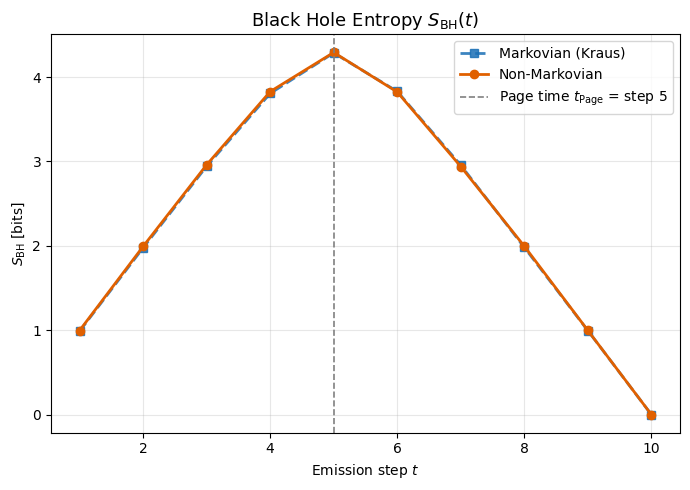

Saved: fig_sbh.pdf


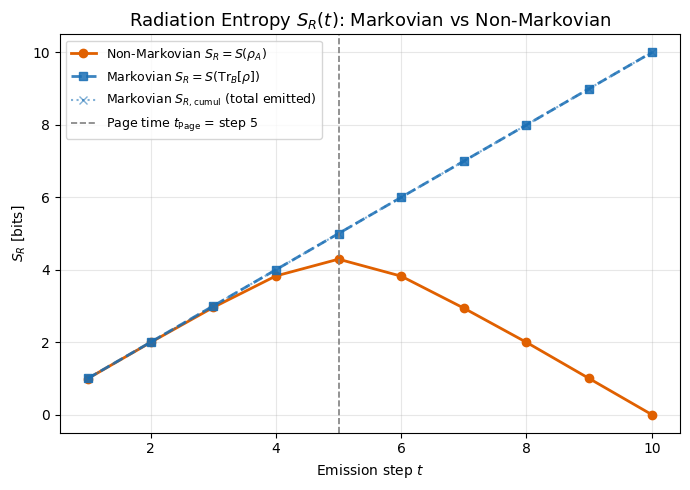

Saved: fig_sr.pdf


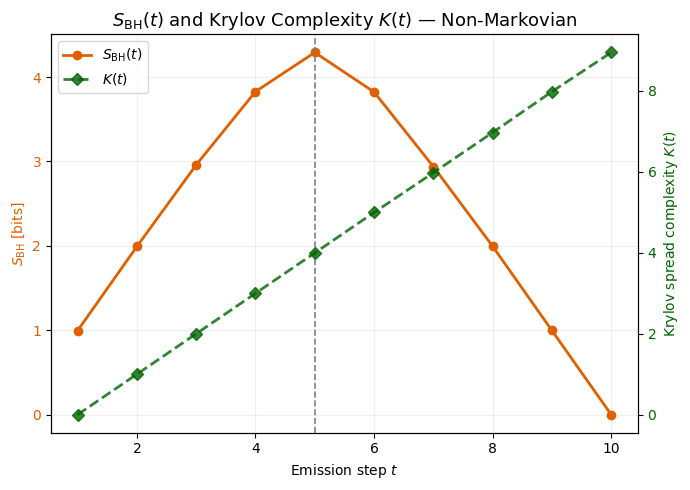

Saved: fig_complexity.pdf


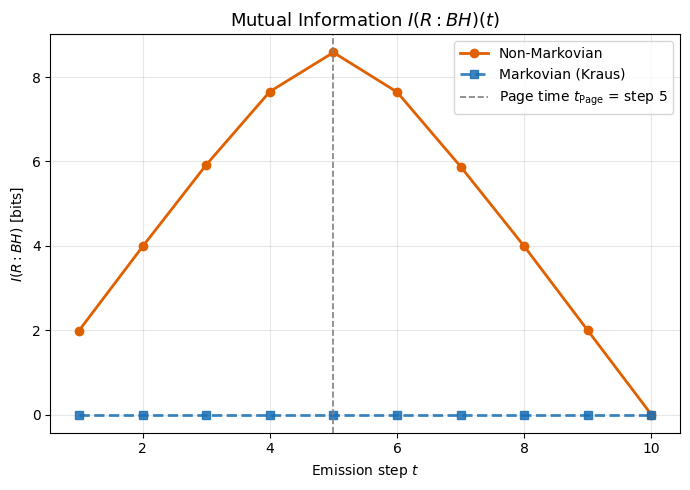

Saved: fig_mi.pdf


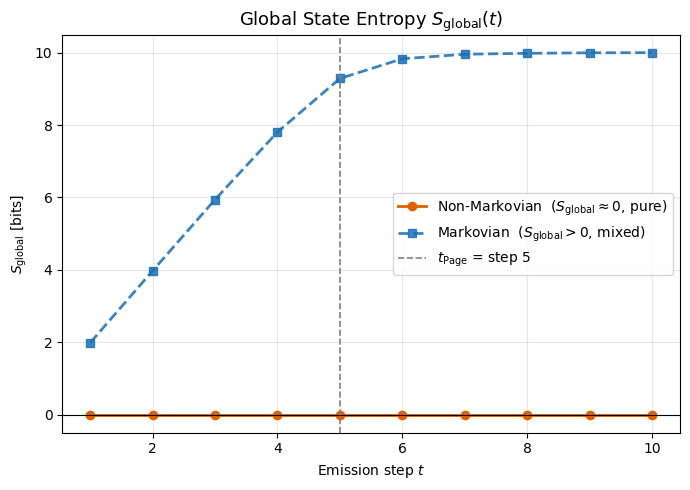

Saved: fig_sglobal.pdf


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# INDIVIDUAL FIGURES
# ─────────────────────────────────────────────────────────────────────────────

# Fig 1: S_BH — Markovian vs Non-Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_m,  ebh_m,  's--', color=C_M,  lw=2, alpha=0.85, label='Markovian (Kraus)')
ax.plot(s_nm, ebh_nm, 'o-',  color=C_NM, lw=2,             label='Non-Markovian')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Black Hole Entropy $S_{\rm BH}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm BH}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sbh.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sbh.pdf')

# Fig 2: S_R — genuine subsystem entropy for both models,
#         plus S_{R,cumul} for Markovian as a separate curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, erad_nm,      'o-',  color=C_NM,      lw=2,
        label=r'Non-Markovian $S_R = S(\rho_A)$')
ax.plot(s_m,  erad_m,       's--', color=C_M,        lw=2, alpha=0.85,
        label=r'Markovian $S_R = S(\mathrm{Tr}_B[\rho])$')
ax.plot(s_m,  erad_cumul_m, 'x:',  color=C_M,        lw=1.5, alpha=0.55,
        label=r'Markovian $S_{R,\mathrm{cumul}}$ (total emitted)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Radiation Entropy $S_R(t)$: Markovian vs Non-Markovian', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_R$ [bits]')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sr.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sr.pdf')

# Fig 3: S_BH and K(t) — Non-Markovian (dual axis)
fig, ax_s = plt.subplots(figsize=(7, 5))
ax_k = ax_s.twinx()
l1, = ax_s.plot(s_nm, ebh_nm, 'o-',  color=C_NM,       lw=2,
                label=r'$S_{\rm BH}(t)$')
l2, = ax_k.plot(s_nm, k_nm,   'D--', color='darkgreen', lw=2, alpha=0.8,
                label=r'$K(t)$')
ax_s.axvline(page_step, color='gray', ls='--', lw=1.2,
             label=f'$t_{{\\rm Page}}$ = step {page_step}')
ax_s.set_ylabel(r'$S_{\rm BH}$ [bits]', color=C_NM)
ax_s.tick_params(axis='y', labelcolor=C_NM)
ax_k.set_ylabel(r'Krylov spread complexity $K(t)$', color='darkgreen')
ax_k.tick_params(axis='y', labelcolor='darkgreen')
ax_s.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax_s.set_title(r'$S_{\rm BH}(t)$ and Krylov Complexity $K(t)$ — Non-Markovian',
               fontsize=13)
ax_s.set_xlabel(r'Emission step $t$')
ax_s.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_complexity.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_complexity.pdf')

# Fig 4: I(R:BH) — Non-Markovian and Markovian
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, mi_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian')
ax.plot(s_m,  mi_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian (Kraus)')
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'Page time $t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Mutual Information $I(R:BH)(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$I(R:BH)$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mi.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_mi.pdf')

# Fig 5: S_global — verifying purity (NM) vs mixing (Markovian Kraus)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_nm, s_global_nm, 'o-',  color=C_NM, lw=2,
        label=r'Non-Markovian  ($S_{\rm global} \approx 0$, pure)')
ax.plot(s_m,  s_global_m,  's--', color=C_M,  lw=2, alpha=0.85,
        label=r'Markovian  ($S_{\rm global} > 0$, mixed)')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1.2,
           label=f'$t_{{\\rm Page}}$ = step {page_step}')
ax.set_title(r'Global State Entropy $S_{\rm global}(t)$', fontsize=13)
ax.set_xlabel(r'Emission step $t$')
ax.set_ylabel(r'$S_{\rm global}$ [bits]')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sglobal.pdf', bbox_inches='tight', dpi=200)
plt.show(); print('Saved: fig_sglobal.pdf')

## BLP Non-Markovianity Measure

**Protocol (Breuer, Laine & Piilo 2009):**
1. Prepare two initial BH states:  
   - Probe 1: $|0\rangle^{\otimes N_{\rm BH}}$  
   - Probe 2: $|{+}\rangle|0\rangle^{\otimes (N_{\rm BH}-1)}$
2. Evolve both through identical NM circuit (fixed random seed — isolates memory from randomness)
3. At each step: partial-trace radiation register → reduced BH state $\rho_{\rm BH}(t)$
4. Compute trace distance $D(t) = \frac{1}{2}\|\rho_1(t) - \rho_2(t)\|_1$
5. BLP measure: $\mathcal{N}_{\rm BLP} = \sum_{\Delta D > 0} \Delta D(t)$

$\mathcal{N}_{\rm BLP} > 0$ $\Leftrightarrow$ information backflow $\Leftrightarrow$ non-Markovian dynamics.

In [ ]:
def run_evaporation_for_blp_radiation(probe: str, seed: int = 42, g0: float = G0_GLOBAL):
    """Same as run_evaporation_for_blp but returns radiation reduced state."""
    np.random.seed(seed)
    # ... same initialisation ...

    step = 0
    while len(bh) > 0:
        step += 1
        # ... same circuit ...
        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)   # ← trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # full state is radiation
        rho_series.append(rho_rad)

    return rho_series

Computing BLP measure  (N_BH=10)...
Probe 1: |0>^N  |  Probe 2: |+>|0>^(N-1)
seed=42 — identical gate angles isolate memory effects.

Trace distances D(t):
  Step  1: D = 0.706132
  Step  2: D = 0.701008
  Step  3: D = 0.687642
  Step  4: D = 0.621423
  Step  5: D = 0.411830
  Step  6: D = 0.228365
  Step  7: D = 0.110397
  Step  8: D = 0.049267
  Step  9: D = 0.009107
  Step 10: D = 0.026645

BLP measure  N_BLP = 0.017538
→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).


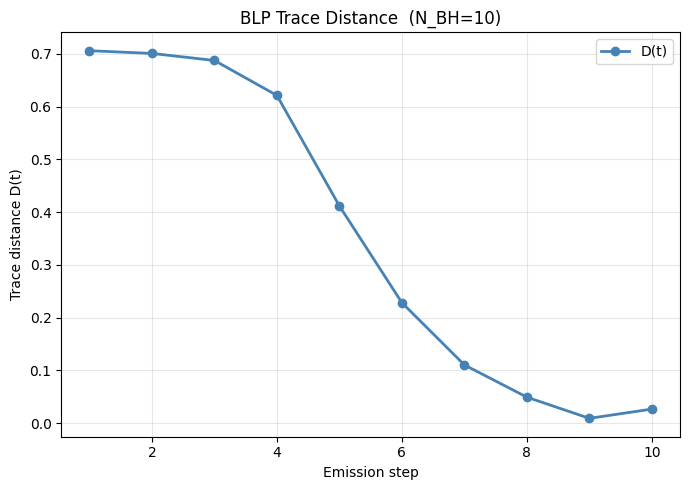

Saved: blp_trace_distance.pdf


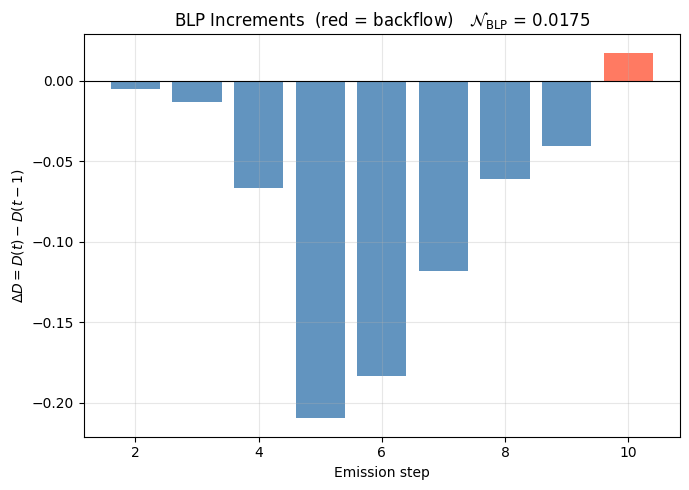

Saved: blp_increments.pdf


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP NON-MARKOVIANITY MEASURE
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
# ─────────────────────────────────────────────────────────────────────────────
N_BH = 10
def trace_distance(rho1, rho2) -> float:
    """D(rho1, rho2) = (1/2) Tr|rho1 - rho2| via eigenvalue decomposition."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))


#def run_evaporation_for_blp(probe: str, seed: int = 42):
def run_evaporation_for_blp(probe: str, seed: int = 42,
                             markovian: bool = False, g0: float = G0_GLOBAL):
    """
    BLP evaporation runner. Returns reduced BH density matrix rho_BH(t)
    at each step via partial trace over the radiation register.

    probe    : 'zero'      -> |0...0>^N_BH
               'plus'      -> |+>|0>^(N_BH-1)
               'ones'      -> |1...1>^N_BH
               'ones_last' -> |0...01>
               'plus_all'  -> |+>^N_BH
               'minus_all' -> |->^N_BH
    seed     : fixed RNG — identical gate angles for both probes isolates
               memory effect from circuit randomness.
    markovian: if True, disables radiation_memory_interaction and
               bh_radiation_backaction (pure scrambling control).
    g0       : base back-action coupling (Hawking-motivated ansatz).
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH          # 'zero'

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)

        if not markovian:
            if len(rad) >= 2:
                radiation_memory_interaction(step_qc, rad)
            if len(rad) > 0:
                bh_radiation_backaction(step_qc, bh, rad,
                                        t=step, N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_interior = partial_trace(state, rad)
        else:
            rho_interior = partial_trace(state, list(range(N_BH - 1)))
        rho_series.append(rho_interior)

    return rho_series


# ── Quick sanity check: single probe pair, seed=42 ───────────────────────────
print(f"Computing BLP measure  (N_BH={N_BH})...")
print(f"Probe 1: |0>^N  |  Probe 2: |+>|0>^(N-1)")
print(f"seed=42 — identical gate angles isolate memory effects.\n")

rho_series_1 = run_evaporation_for_blp('zero', seed=42, g0=G0_GLOBAL)
rho_series_2 = run_evaporation_for_blp('plus', seed=42, g0=G0_GLOBAL)

T         = min(len(rho_series_1), len(rho_series_2))
D_values  = [trace_distance(rho_series_1[t], rho_series_2[t]) for t in range(T)]
steps_blp = list(range(1, T + 1))
dD        = np.diff(D_values)
N_BLP     = float(np.sum(dD[dD > 0]))

print("Trace distances D(t):")
for t, d in zip(steps_blp, D_values):
    print(f"  Step {t:2d}: D = {d:.6f}")
print(f"\nBLP measure  N_BLP = {N_BLP:.6f}")
if N_BLP > 1e-6:
    print("→ N_BLP > 0 — CONFIRMED non-Markovian (BLP criterion satisfied).")
else:
    print("→ N_BLP ≈ 0 — no detectable backflow.")

# ── BLP plots ──────────────────────────────────
# Fig: BLP trace distance
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(steps_blp, D_values, 'o-', color='steelblue', lw=2, label='D(t)')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance D(t)")
ax.set_title(f"BLP Trace Distance  (N_BH={N_BH})")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig("blp_trace_distance.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_trace_distance.pdf")

# Fig: BLP increments
fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
ax.bar(steps_blp[1:], dD, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Emission step"); ax.set_ylabel(r"$\Delta D = D(t) - D(t-1)$")
ax.set_title(
    f"BLP Increments  (red = backflow)   "
    r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_increments.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_increments.pdf")

<>:76: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_483/3615307950.py:76: SyntaxWarning: invalid escape sequence '\c'
  ('zero', 'ones_last', r"$|0\rangle^N$ vs $|0\cdots01\rangle$",


Computing BLP measure  (N_BH=10)...

────────────────────────────────────────────────────────────
Pair 1: non-orthogonal  [lower bound, D₀ ≈ 0.665]
Trace distances D(t):
  Step  1: D = 0.706132
  Step  2: D = 0.701008
  Step  3: D = 0.687642
  Step  4: D = 0.621423
  Step  5: D = 0.411830
  Step  6: D = 0.228365
  Step  7: D = 0.110397
  Step  8: D = 0.049267
  Step  9: D = 0.009107
  Step 10: D = 0.026645
N_BLP = 0.017538  →  non-Markovian confirmed

────────────────────────────────────────────────────────────
Pair 2: orthogonal (global flip)  [orthogonal, D₀ = 1.0]
Trace distances D(t):
  Step  1: D = 0.968801
  Step  2: D = 0.991985
  Step  3: D = 0.967655
  Step  4: D = 0.880988
  Step  5: D = 0.553306
  Step  6: D = 0.278266
  Step  7: D = 0.188346
  Step  8: D = 0.070620
  Step  9: D = 0.043683
  Step 10: D = 0.031401
N_BLP = 0.023184  →  non-Markovian confirmed

────────────────────────────────────────────────────────────
Pair 3: orthogonal (single flip)  [orthogonal, D₀ = 1.0]


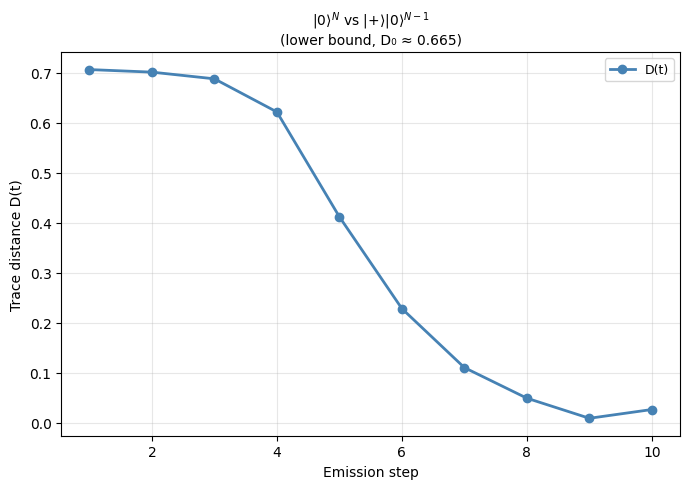

Saved: blp_P1_trace.pdf


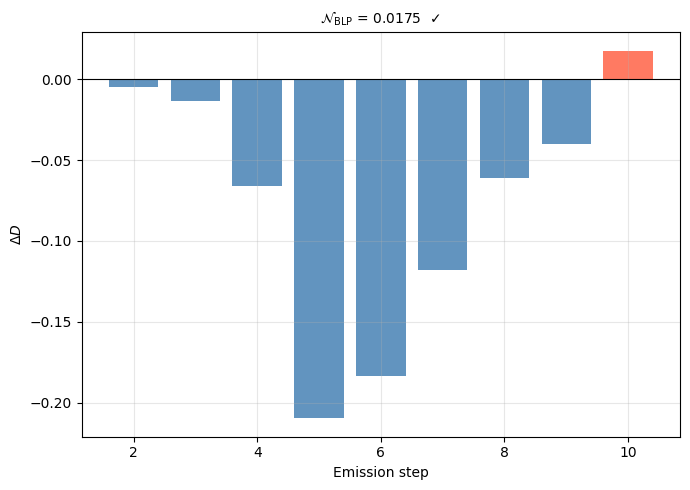

Saved: blp_P1_increments.pdf


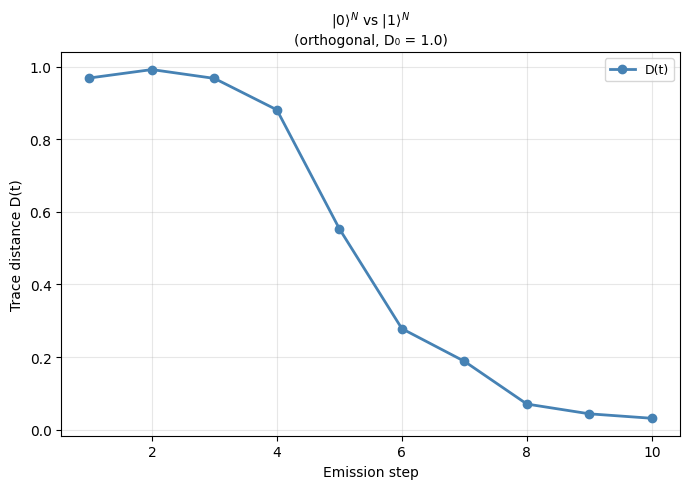

Saved: blp_P2_trace.pdf


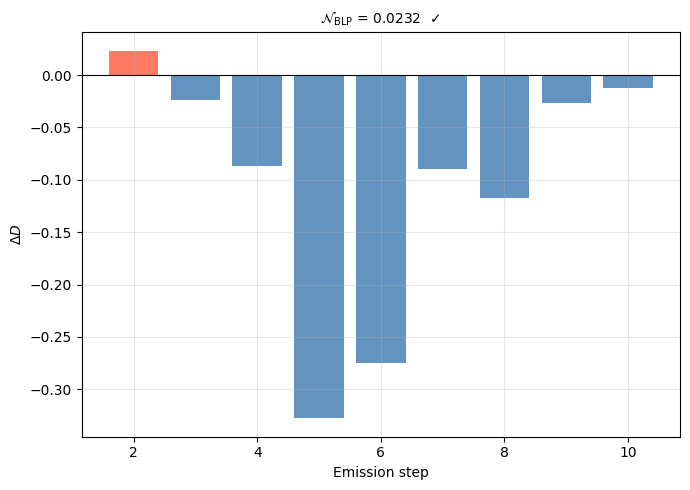

Saved: blp_P2_increments.pdf


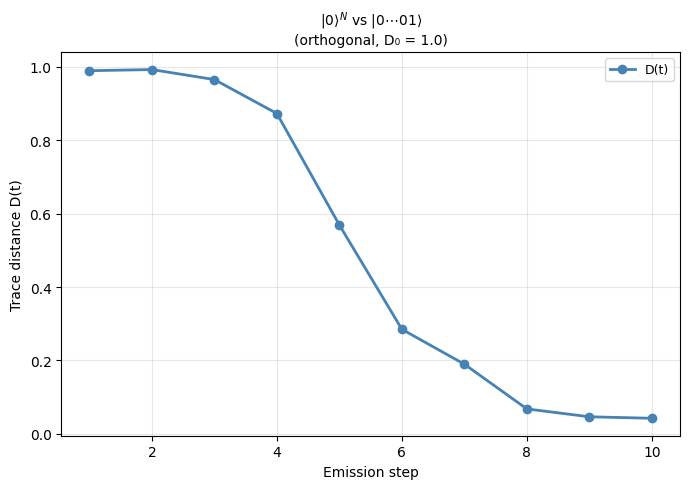

Saved: blp_P3_trace.pdf


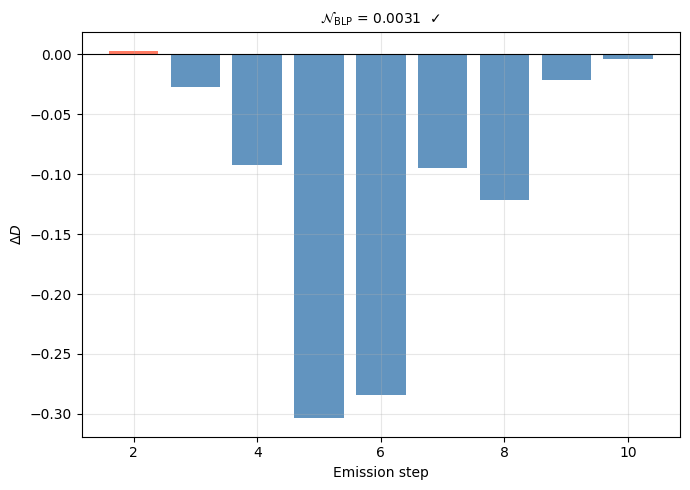

Saved: blp_P3_increments.pdf


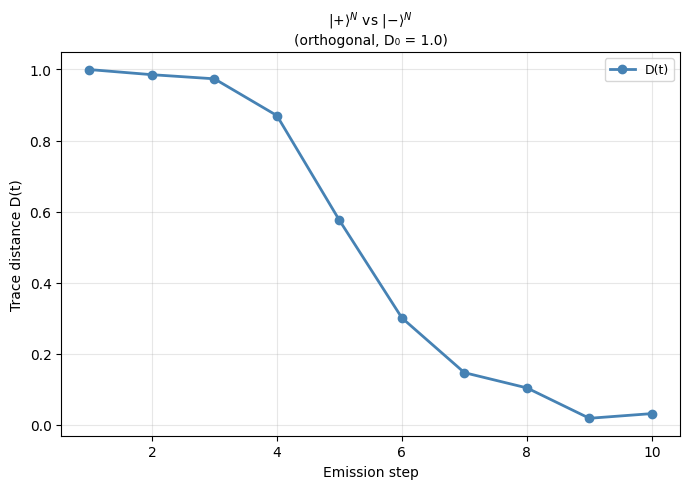

Saved: blp_P4_trace.pdf


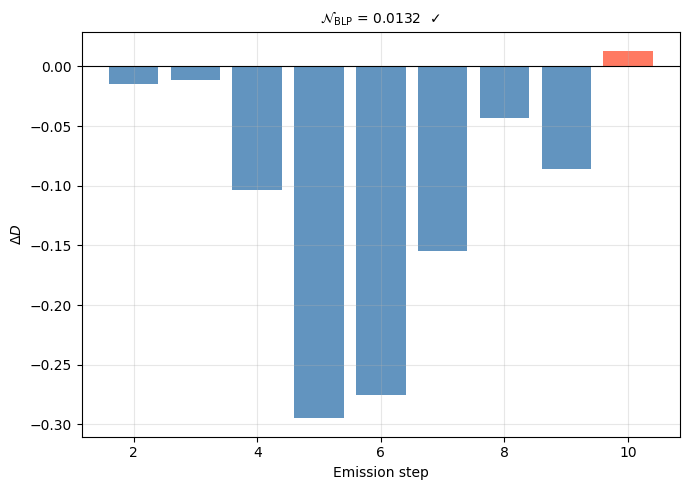

Saved: blp_P4_increments.pdf


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP NON-MARKOVIANITY MEASURE
# Breuer, Laine & Piilo, PRL 103, 210401 (2009)
# ─────────────────────────────────────────────────────────────────────────────
N_BH = 10

def trace_distance(rho1, rho2) -> float:
    """D(rho1, rho2) = (1/2) Tr|rho1 - rho2| via eigenvalue decomposition."""
    eigvals = np.linalg.eigvalsh(rho1.data - rho2.data)
    return 0.5 * float(np.sum(np.abs(eigvals)))

def run_evaporation_for_blp(probe: str, seed: int = 100, markovian: bool = False, g0: float = G0_GLOBAL):
    """
    probe : 'zero'     -> |0...0>^N
            'plus'     -> |+>|0>^(N-1)
            'ones'     -> |1...1>^N
            'ones_last'-> |0...01>
            'plus_all' -> |+>^N
            'minus_all'-> |->^N
    seed  : fixed — identical gate angles isolate memory effects.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH          # 'zero'

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    while len(bh) > 0:
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad, t=len(rad), N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_interior = partial_trace(state, rad)
        else:
            rho_interior = partial_trace(state, list(range(N_BH - 1)))
        rho_series.append(rho_interior)

    return rho_series

'''
def compute_blp_pair(probe_a, probe_b, label_a, label_b, series_cache):
    """Compute D(t), dD, N_BLP for a probe pair. Uses cache to avoid re-running."""
    if probe_a not in series_cache:
        series_cache[probe_a] = run_evaporation_for_blp(probe_a, seed=42, g0=G0_GLOBAL)
    if probe_b not in series_cache:
        series_cache[probe_b] = run_evaporation_for_blp(probe_b, seed=42, g0=G0_GLOBAL)
    s_a, s_b = series_cache[probe_a], series_cache[probe_b]
    T = min(len(s_a), len(s_b))
    D_vals = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
    steps  = list(range(1, T + 1))
    dD     = np.diff(D_vals)
    N_BLP  = float(np.sum(dD[dD > 0]))
    return steps, D_vals, dD, N_BLP


# ── Define all four pairs ─────────────────────────────────────────────────────
pairs = [
    ('zero', 'plus',      r"$|0\rangle^N$ vs $|{+}\rangle|0\rangle^{N-1}$",
                          "lower bound, D₀ ≈ 0.665",  "non-orthogonal"),
    ('zero', 'ones',      r"$|0\rangle^N$ vs $|1\rangle^N$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (global flip)"),
    ('zero', 'ones_last', r"$|0\rangle^N$ vs $|0\cdots01\rangle$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (single flip)"),
    ('plus_all','minus_all', r"$|{+}\rangle^N$ vs $|{-}\rangle^N$",
                          "orthogonal, D₀ = 1.0",      "orthogonal (coherent)"),
]
'''
# ── Run all pairs ─────────────────────────────────────────────────────────────
print(f"Computing BLP measure  (N_BH={N_BH})...")
cache   = {}
results = []

for i, (pa, pb, tex_label, d0_note, short) in enumerate(pairs, 1):
    print(f"\n{'─'*60}")
    print(f"Pair {i}: {short}  [{d0_note}]")
    steps, D_vals, dD, N_BLP = compute_blp_pair(pa, pb, pa, pb, cache)
    results.append((steps, D_vals, dD, N_BLP, tex_label, d0_note))

    print("Trace distances D(t):")
    for t, d in zip(steps, D_vals):
        print(f"  Step {t:2d}: D = {d:.6f}")
    print(f"N_BLP = {N_BLP:.6f}  →  {'non-Markovian confirmed' if N_BLP > 1e-6 else 'no detectable backflow'}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'Pair':<45} {'N_BLP':>10}")
print(f"  {'─'*45}  {'─'*8}")
for i, ((pa, pb, _, d0_note, short), (_, _, _, N_BLP, _, _)) in enumerate(zip(pairs, results), 1):
    flag = "✓ non-Markovian" if N_BLP > 1e-6 else "✗ no backflow"
    print(f"  {short:<42} {N_BLP:>10.6f}  {flag}")
print(f"{'='*60}")

# ── 4 plots ─────────────────────────────────────────────────────────────

for row, (steps, D_vals, dD, N_BLP, tex_label, d0_note) in enumerate(results):
    pair_tag = f"P{row+1}"

    # Trace distance
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(steps, D_vals, 'o-', color='steelblue', lw=2, label='D(t)')
    ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance D(t)")
    ax.set_title(f"{tex_label}\n({d0_note})", fontsize=10)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_trace.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_trace.pdf")

    # Increments
    fig, ax = plt.subplots(figsize=(7, 5))
    bar_colors = ['tomato' if d > 0 else 'steelblue' for d in dD]
    ax.bar(steps[1:], dD, color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel("Emission step"); ax.set_ylabel(r"$\Delta D$")
    ax.set_title(
        r"$\mathcal{N}_{\rm BLP}$" + f" = {N_BLP:.4f}"
        + ("  ✓" if N_BLP > 1e-6 else "  ✗"),
        fontsize=10
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"blp_{pair_tag}_increments.pdf", bbox_inches='tight', dpi=200)
    plt.show(); print(f"Saved: blp_{pair_tag}_increments.pdf")

BLP Seed Robustness  (N_BH=10)
Seeds tested: [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170]

Running Markovian control (memory terms disabled)...

Probe pair                           seed=50  seed=55  seed=60  seed=65  seed=70  seed=75  seed=80  seed=85  seed=90  seed=95  seed=100  seed=105  seed=110  seed=115  seed=120  seed=125  seed=130  seed=135  seed=140  seed=145  seed=150  seed=155  seed=160  seed=165  seed=170    mean ± std
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P1: |0>^N vs |+>|0>^(N-1)             0.00817   0.01849   0.01020   0.02506   0.00000   0.00000   0.00062   0.00000   0.00930   0.00852   0.00569   0.03960   0.01226   0.00648   0.00000   0.00000   0.0000

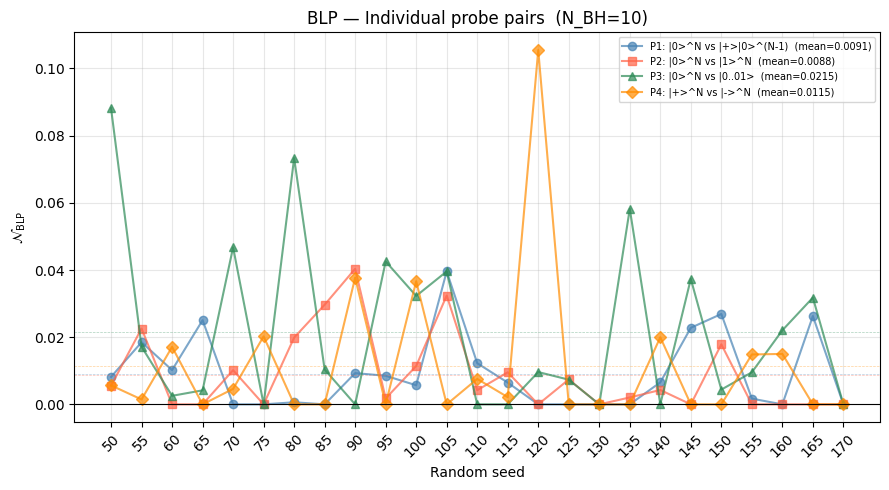

Saved: blp_robustness_individual.pdf


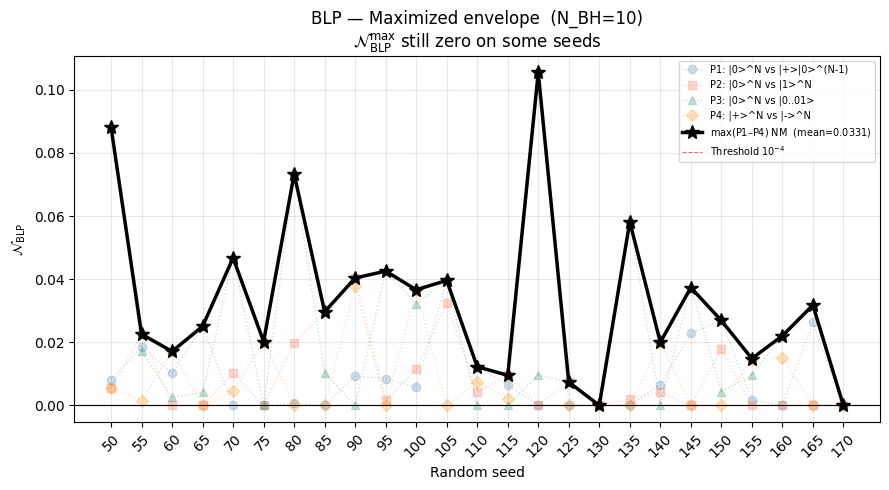

Saved: blp_robustness_envelope.pdf


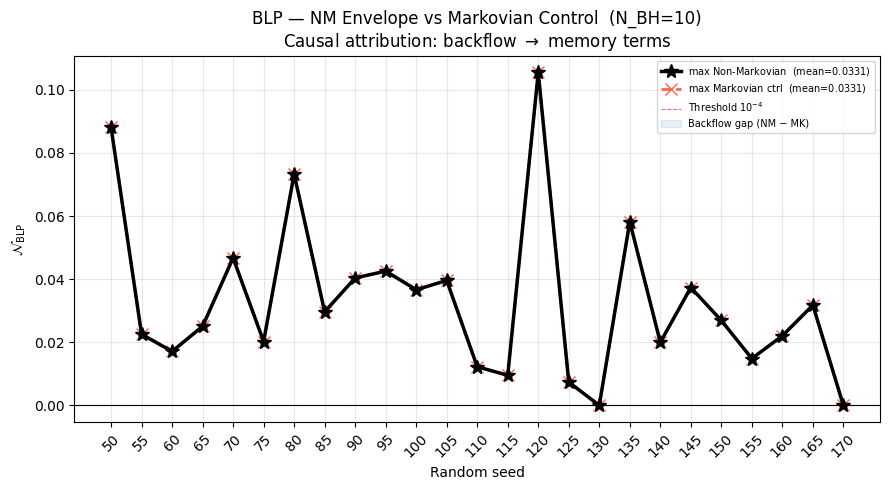

Saved: blp_robustness_control.pdf


In [51]:

# ─────────────────────────────────────────────────────────────────────────────
# BLP SEED ROBUSTNESS TABLE + MAXIMIZED ENVELOPE + MARKOVIAN CONTROL
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

SEEDS       = [i for i in range(50, 172, 5)]
PROBE_PAIRS = [
    ('zero',     'plus',      "P1: |0>^N vs |+>|0>^(N-1)"),
    ('zero',     'ones',      "P2: |0>^N vs |1>^N"),
    ('zero',     'ones_last', "P3: |0>^N vs |0..01>"),
    ('plus_all', 'minus_all', "P4: |+>^N vs |->^N"),
]

MAX_PAIRS = [('zero', 'plus'), ('zero', 'ones_last'),
             ('zero', 'ones'), ('plus_all', 'minus_all')]

print(f"BLP Seed Robustness  (N_BH={N_BH})")
print(f"Seeds tested: {SEEDS}\n")

# ── Per-pair non-Markovian table ──────────────────────────────────────────────
table = {}
for pa, pb, plabel in PROBE_PAIRS:
    table[plabel] = {}
    for seed in SEEDS:
        s_a = run_evaporation_for_blp(pa, seed=seed, g0=G0_GLOBAL)
        s_b = run_evaporation_for_blp(pb, seed=seed, g0=G0_GLOBAL)
        T   = min(len(s_a), len(s_b))
        D   = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD  = np.diff(D)
        table[plabel][seed] = float(np.sum(dD[dD > 0]))

# ── Maximized envelope ────────────────────────────────────────────────────────
maximized = {}
for seed in SEEDS:
    # Reuse values already computed — no need to re-run simulations
    p1_label = "P1: |0>^N vs |+>|0>^(N-1)"
    p2_label = "P2: |0>^N vs |1>^N"
    p3_label = "P3: |0>^N vs |0..01>"
    p4_label = "P4: |+>^N vs |->^N"
    maximized[seed] = max(
        table[p1_label][seed],
        table[p2_label][seed],
        table[p3_label][seed],
        table[p4_label][seed],
    )

max_vals   = np.array([maximized[s] for s in SEEDS])
max_mean   = max_vals.mean()
max_std    = max_vals.std()
max_robust = np.all(max_vals > 1e-4)

# ── Markovian control: maximized over same four pairs ─────────────────────────
print("Running Markovian control (memory terms disabled)...")
mk_table = {}
for pa, pb, plabel in PROBE_PAIRS:
    mk_table[plabel] = {}
    for seed in SEEDS:
        s_a = run_evaporation_for_blp(pa, seed=seed, markovian=True, g0=G0_GLOBAL)
        s_b = run_evaporation_for_blp(pb, seed=seed, markovian=True, g0=G0_GLOBAL)
        T   = min(len(s_a), len(s_b))
        D   = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD  = np.diff(D)
        mk_table[plabel][seed] = float(np.sum(dD[dD > 0]))

mk_maximized = {}
for seed in SEEDS:
    mk_maximized[seed] = max(
        mk_table[p1_label][seed],
        mk_table[p2_label][seed],
        mk_table[p3_label][seed],
        mk_table[p4_label][seed],
    )

mk_max_vals = np.array([mk_maximized[s] for s in SEEDS])
mk_mean     = mk_max_vals.mean()
mk_std      = mk_max_vals.std()

# ── Print raw table ───────────────────────────────────────────────────────────
header = f"{'Probe pair':<35}" + "".join(f"  seed={s}" for s in SEEDS) + "    mean ± std"
print(f"\n{header}")
print("─" * len(header))

summary = {}
for plabel, seed_vals in table.items():
    vals = np.array([seed_vals[s] for s in SEEDS])
    mean = vals.mean()
    std  = vals.std()
    summary[plabel] = (vals, mean, std)
    row  = f"{plabel:<35}"
    row += "".join(f"  {seed_vals[s]:>8.5f}" for s in SEEDS)
    row += f"    {mean:.5f} ± {std:.5f}"
    print(row)

row  = f"{'MAX(P1,P2,P3,P4) [NM]':<35}"
row += "".join(f"  {maximized[s]:>8.5f}" for s in SEEDS)
row += f"    {max_mean:.5f} ± {max_std:.5f}"
print(row)

row  = f"{'MAX(P1,P2,P3,P4) [MK]':<35}"
row += "".join(f"  {mk_maximized[s]:>8.5f}" for s in SEEDS)
row += f"    {mk_mean:.5f} ± {mk_std:.5f}"
print(row)

# ── Verdict ───────────────────────────────────────────────────────────────────
print("\nVerdict (N_BLP > 1e-4 on ALL seeds = robust):")
for plabel, (vals, mean, std) in summary.items():
    always_positive = np.all(vals > 1e-4)
    sometimes       = np.any(vals > 1e-4)
    if always_positive:
        verdict = "ROBUST  — positive on every seed"
    elif sometimes:
        verdict = "PARTIAL — positive on some seeds only"
    else:
        verdict = "NULL    — no backflow detected"
    print(f"  {plabel:<35} {verdict}")

print(f"  {'MAX [Non-Markovian]':<35} "
      f"{'ROBUST  — positive on every seed' if max_robust else 'PARTIAL — some seeds still zero'}")
mk_robust = np.all(mk_max_vals > 1e-4)
print(f"  {'MAX [Markovian ctrl]':<35} "
      f"{'ROBUST' if mk_robust else 'NULL / PARTIAL — as expected'}")

# ── Plots ─────────────────────────────────────────────────────────────────────
markers = ['o', 's', '^', 'D']
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# Fig 1: Individual probe pairs
fig, ax = plt.subplots(figsize=(9, 5))
for (plabel, (vals, mean, std)), marker, color in zip(summary.items(), markers, colors):
    ax.plot(SEEDS, vals, marker=marker, color=color, lw=1.5, alpha=0.7,
            label=f"{plabel}  (mean={mean:.4f})")
    ax.axhline(mean, color=color, lw=0.5, ls='--', alpha=0.4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(f"BLP — Individual probe pairs  (N_BH={N_BH})")
ax.set_xticks(SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_robustness_individual.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_robustness_individual.pdf")

# Fig 2: Maximized envelope
fig, ax = plt.subplots(figsize=(9, 5))
for (plabel, (vals, mean, std)), marker, color in zip(summary.items(), markers, colors):
    ax.plot(SEEDS, vals, marker=marker, color=color, lw=1.0,
            alpha=0.25, ls=':', label=f"{plabel}")
ax.plot(SEEDS, max_vals, marker='*', color='black', lw=2.5, markersize=10,
        label=r"$\max$(P1–P4) NM  " + f"(mean={max_mean:.4f})", zorder=5)
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6, label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    f"BLP — Maximized envelope  (N_BH={N_BH})\n"
    + (r"$\mathcal{N}_{\rm BLP}^{\max} > 0$ on all seeds — ROBUST"
       if max_robust else
       r"$\mathcal{N}_{\rm BLP}^{\max}$ still zero on some seeds")
)
ax.set_xticks(SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_robustness_envelope.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_robustness_envelope.pdf")

# Fig 3: NM envelope vs Markovian control
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(SEEDS, max_vals,    marker='*', color='black',  lw=2.5, markersize=10,
        label=r"$\max$ Non-Markovian" + f"  (mean={max_mean:.4f})", zorder=5)
ax.plot(SEEDS, mk_max_vals, marker='x', color='tomato', lw=2.0, markersize=8,
        ls='--', label=r"$\max$ Markovian ctrl" + f"  (mean={mk_mean:.4f})", zorder=4)
ax.axhline(1e-4, color='red', lw=0.8, ls='--', alpha=0.6, label="Threshold $10^{-4}$")
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(SEEDS, mk_max_vals, max_vals,
                alpha=0.12, color='steelblue', label="Backflow gap (NM − MK)")
ax.set_xlabel("Random seed"); ax.set_ylabel(r"$\mathcal{N}_{\rm BLP}$")
ax.set_title(
    f"BLP — NM Envelope vs Markovian Control  (N_BH={N_BH})\n"
    r"Causal attribution: backflow $\rightarrow$ memory terms"
)
ax.set_xticks(SEEDS); ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_robustness_control.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_robustness_control.pdf")

## BLP Non-Markovianity with Varying Back-action Coupling `g0`

To investigate how to increase distinguishability (or information backflow), we can vary the `g0` parameter, which controls the strength of the `bh_radiation_backaction`. A larger `g0` implies stronger non-Markovian effects.

In [23]:
import math, heapq

G0_SWEEP_VALUES = [
    0.001, 0.1, np.pi/8, 0.5, np.pi/4, np.pi/2, 0.75*np.pi, np.pi,
]

SWEEP_PROBE_PAIR = ('zero', 'ones_last', "P3: $|0>^{N}$ vs $|0..01>$")
SWEEP_SEED = [i for i in range(90, 151, 5)]

print(f"Sweeping g0 values for probe pair: {SWEEP_PROBE_PAIR[2]} (seed={SWEEP_SEED})")

blp_g0_results = {}
best_val = -np.inf
best_g0  = None
best_seed = None
top_n = []


for g0_val in G0_SWEEP_VALUES:
    n_blp_for_seeds = []
    for seed_val in SWEEP_SEED:
        s_a = run_evaporation_for_blp(SWEEP_PROBE_PAIR[0], seed=seed_val, g0=g0_val)
        s_b = run_evaporation_for_blp(SWEEP_PROBE_PAIR[1], seed=seed_val, g0=g0_val)

        T = min(len(s_a), len(s_b))
        D_values = [trace_distance(s_a[t], s_b[t]) for t in range(T)]
        dD = np.diff(D_values)
        N_BLP_val = float(np.sum(dD[dD > 0]))

        # Always append the N_BLP_val for the heatmap, regardless of top_n logic
        n_blp_for_seeds.append(N_BLP_val)

        # Heapq logic for tracking top N_BLP values
        heapq.heappush(top_n, (N_BLP_val, g0_val, seed_val))
        if len(top_n) > 5:
            heapq.heappop(top_n)

        # Track the global best
        if N_BLP_val > best_val:
            best_val  = N_BLP_val
            best_g0   = g0_val
            best_seed = seed_val

    blp_g0_results[g0_val] = {
        'N_BLP_values': n_blp_for_seeds,
        'N_BLP_mean': np.mean(n_blp_for_seeds),
        'N_BLP_std':  np.std(n_blp_for_seeds)
    }
print("\nTop 5 combinations:")
for val, g0, seed in sorted(top_n, reverse=True):
    print(f"  g0 = {g0:.6f}, seed = {seed}, N_BLP = {val:.6f}")
print("\nBLP N_BLP (mean \u00b1 std) values for various g0 over multiple seeds:")
for g0, data in blp_g0_results.items():
    print(f"  g0 = {g0:.3f}: N_BLP = {data['N_BLP_mean']:.6f} \u00b1 {data['N_BLP_std']:.6f}")

print(f"\n\u2605 Best combination: g0 = {best_g0:.6f}, seed = {best_seed}, N_BLP = {best_val:.6f}")

Sweeping g0 values for probe pair: P3: $|0>^{N}$ vs $|0..01>$ (seed=[90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150])

Top 5 combinations:
  g0 = 0.500000, seed = 135, N_BLP = 0.075525
  g0 = 0.392699, seed = 135, N_BLP = 0.074254
  g0 = 0.785398, seed = 135, N_BLP = 0.068322
  g0 = 3.141593, seed = 135, N_BLP = 0.058200
  g0 = 2.356194, seed = 135, N_BLP = 0.058200

BLP N_BLP (mean ± std) values for various g0 over multiple seeds:
  g0 = 0.001: N_BLP = 0.003901 ± 0.006157
  g0 = 0.100: N_BLP = 0.006476 ± 0.009942
  g0 = 0.393: N_BLP = 0.015984 ± 0.021467
  g0 = 0.500: N_BLP = 0.016450 ± 0.024012
  g0 = 0.785: N_BLP = 0.016121 ± 0.019636
  g0 = 1.571: N_BLP = 0.017795 ± 0.020098
  g0 = 2.356: N_BLP = 0.017795 ± 0.020098
  g0 = 3.142: N_BLP = 0.017795 ± 0.020098

★ Best combination: g0 = 0.500000, seed = 135, N_BLP = 0.075525


In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for array operations

# Plotting the BLP N_BLP vs g0 values

g0_keys = list(blp_g0_results.keys())
n_blp_means = [blp_g0_results[g]['N_BLP_mean'] for g in g0_keys]

plt.figure(figsize=(10, 6))
plt.plot(g0_keys, n_blp_means, 'o-', color='purple', lw=2)
plt.axvline(np.pi / 2, color='red', linestyle='--', label=r'Capping limit $\pi/2$')
plt.xlabel(r'$g_0$ (base back-action strength)')
plt.ylabel(r'$\mathcal{N}_{\rm BLP}$  (probe pair P3)')
plt.title(f'Effect of $g_0$ on BLP Non-Markovianity  (N_BH={N_BH}, seed={SWEEP_SEED})')
plt.grid(alpha=0.3)
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.savefig("blp_g0_sweep.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_sweep.pdf")


# --- Heatmap for g0 and seeds ---

# Prepare data for heatmap
heatmap_data = []
for g0_val in G0_SWEEP_VALUES:
    # Assuming N_BLP_values in blp_g0_results is a list corresponding to SWEEP_SEED
    heatmap_data.append(blp_g0_results[g0_val]['N_BLP_values'])

heatmap_data = np.array(heatmap_data)

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data, cmap='viridis', origin='lower', aspect='auto',
           extent=[SWEEP_SEED[0], SWEEP_SEED[-1], G0_SWEEP_VALUES[0], G0_SWEEP_VALUES[-1]])

plt.colorbar(label=r'$\mathcal{N}_{\rm BLP}$ (Non-Markovianity Measure)')

# Customizing ticks to show actual g0 and seed values
plt.xticks(SWEEP_SEED, rotation=90)
plt.yticks(G0_SWEEP_VALUES)

plt.xlabel('Random Seed')
plt.ylabel(r'$g_0$ (base back-action strength)')
plt.title(f'Heatmap of BLP Non-Markovianity by $g_0$ and Seed (N_BH={N_BH}, Probe={SWEEP_PROBE_PAIR[2]})')
plt.tight_layout()
plt.savefig("blp_g0_seed_heatmap.pdf", bbox_inches='tight', dpi=200)
plt.show()
print("Saved: blp_g0_seed_heatmap.pdf")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLP DIAGNOSTIC: D_BH(t) vs D_R(t)
# Where is the distinguishability living — BH interior or radiation?
# ─────────────────────────────────────────────────────────────────────────────

DIAG_PROBE_A = 'zero'
DIAG_PROBE_B = 'plus'
DIAG_SEED    = 42

def run_evaporation_for_blp_radiation(probe: str, seed: int = 42,
                                       g0: float = G0_GLOBAL):
    """
    Same circuit as run_evaporation_for_blp but returns
    reduced RADIATION density matrix at each step.
    """
    np.random.seed(seed)

    if   probe == 'plus':      init_label = '+' + '0' * (N_BH - 1)
    elif probe == 'ones':      init_label = '1' * N_BH
    elif probe == 'ones_last': init_label = '0' * (N_BH - 1) + '1'
    elif probe == 'plus_all':  init_label = '+' * N_BH
    elif probe == 'minus_all': init_label = '-' * N_BH
    else:                      init_label = '0' * N_BH

    state = Statevector.from_label(init_label)
    bh, rad, rho_series = list(range(N_BH)), [], []

    step = 0
    while len(bh) > 0:
        step += 1
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)
        if len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if len(rad) > 0:
            bh_radiation_backaction(step_qc, bh, rad,
                                    t=step, N_BH_total=N_BH, g0=g0)

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)

        if len(bh) > 0:
            rho_rad = partial_trace(state, bh)    # trace out BH, keep radiation
        else:
            rho_rad = partial_trace(state, [])    # final step: all is radiation
        rho_series.append(rho_rad)

    return rho_series


# ── Run both subsystems for the same probe pair and seed ─────────────────────
print(f"BH vs Radiation distinguishability diagnostic")
print(f"Probe A: {DIAG_PROBE_A}  |  Probe B: {DIAG_PROBE_B}  |  seed={DIAG_SEED}")
print(f"N_BH = {N_BH}  |  Page time ≈ step {N_BH // 2}\n")

# BH interior series (already have this function)
rho_bh_a = run_evaporation_for_blp(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_bh_b = run_evaporation_for_blp(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

# Radiation series
rho_rad_a = run_evaporation_for_blp_radiation(DIAG_PROBE_A, seed=DIAG_SEED, g0=G0_GLOBAL)
rho_rad_b = run_evaporation_for_blp_radiation(DIAG_PROBE_B, seed=DIAG_SEED, g0=G0_GLOBAL)

T      = min(len(rho_bh_a), len(rho_bh_b), len(rho_rad_a), len(rho_rad_b))
steps  = list(range(1, T + 1))

D_BH  = [trace_distance(rho_bh_a[t],  rho_bh_b[t])  for t in range(T)]
D_R   = [trace_distance(rho_rad_a[t], rho_rad_b[t]) for t in range(T)]
D_sum = [D_BH[t] + D_R[t] for t in range(T)]

dD_BH = np.diff(D_BH)
dD_R  = np.diff(D_R)

N_BLP_BH = float(np.sum(dD_BH[dD_BH > 0]))
N_BLP_R  = float(np.sum(dD_R[dD_R   > 0]))

page_step = N_BH // 2

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Step':>5}  {'D_BH(t)':>10}  {'D_R(t)':>10}  "
      f"{'D_BH+D_R':>10}  {'ΔD_BH':>8}  {'ΔD_R':>8}  {'era':>12}")
print("─" * 75)
for i, t in enumerate(steps):
    era  = "pre-Page " if t <= page_step else "post-Page"
    dBH  = f"{dD_BH[i-1]:+.5f}" if i > 0 else "    —    "
    dR   = f"{dD_R[i-1]:+.5f}"  if i > 0 else "    —    "
    print(f"{t:>5}  {D_BH[i]:>10.6f}  {D_R[i]:>10.6f}  "
          f"{D_sum[i]:>10.6f}  {dBH:>8}  {dR:>8}  {era:>12}")

print(f"\nN_BLP (BH interior)  = {N_BLP_BH:.6f}")
print(f"N_BLP (radiation)    = {N_BLP_R:.6f}")
print()

# ── Interpret ─────────────────────────────────────────────────────────────────
post_page_D_BH = [D_BH[i]  for i, t in enumerate(steps) if t > page_step]
post_page_D_R  = [D_R[i]   for i, t in enumerate(steps) if t > page_step]

print("Distinguishability after Page time:")
print(f"  Mean D_BH (post-Page) = {np.mean(post_page_D_BH):.6f}")
print(f"  Mean D_R  (post-Page) = {np.mean(post_page_D_R):.6f}")

if np.mean(post_page_D_R) > np.mean(post_page_D_BH):
    print("\n  → Distinguishability has migrated to radiation after Page time.")
    print("    Information left the BH interior and is encoded in radiation.")
    print("    BLP_BH detects only early-time backflow; late-time info is in R.")
elif np.mean(post_page_D_R) < 1e-4 and np.mean(post_page_D_BH) < 1e-4:
    print("\n  → Both D_BH and D_R near zero post-Page.")
    print("    Scrambler has erased initial condition globally.")
    print("    Neither subsystem retains probe-state distinguishability.")
else:
    print("\n  → Mixed picture — check individual step values.")

# ── Plot ──────────────────────────────────────────────────────────────────────
page_step_diag = int(np.argmax(D_BH)) + 1  # use data, not N_BH//2

# Fig 1: D_BH and D_R
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(steps, D_BH, 'o-', color='steelblue', lw=2, label=r'$D_{BH}(t)$')
ax.plot(steps, D_R,  's-', color='tomato',    lw=2, label=r'$D_{R}(t)$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label=f'Page time = {page_step}')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance D(t)")
ax.set_title("BH interior vs Radiation distinguishability")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_crossover.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_crossover.pdf")

# Fig 2: ΔD_BH and ΔD_R
fig, ax = plt.subplots(figsize=(7, 5))
bar_x = steps[1:]; w = 0.35
ax.bar([x - w/2 for x in bar_x], dD_BH,
       width=w, color=['tomato' if d > 0 else 'steelblue' for d in dD_BH],
       alpha=0.8, label=r'$\Delta D_{BH}$')
ax.bar([x + w/2 for x in bar_x], dD_R,
       width=w, color=['darkorange' if d > 0 else 'seagreen' for d in dD_R],
       alpha=0.8, label=r'$\Delta D_{R}$')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(page_step, color='gray', ls='--', lw=1)
ax.set_xlabel("Emission step"); ax.set_ylabel(r"$\Delta D$")
ax.set_title(
    r"Backflow increments  $\mathcal{N}_{BLP}^{BH}$=" + f"{N_BLP_BH:.4f}  "
    r"$\mathcal{N}_{BLP}^{R}$=" + f"{N_BLP_R:.4f}"
)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_increments.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_increments.pdf")

# Fig 3: Total distinguishability budget
fig, ax = plt.subplots(figsize=(7, 5))
ax.fill_between(steps, 0,     D_BH,  alpha=0.4, color='steelblue', label=r'$D_{BH}$')
ax.fill_between(steps, D_BH, D_sum,  alpha=0.4, color='tomato',    label=r'$D_{R}$')
ax.plot(steps, D_sum, 'k-', lw=1.5, label=r'$D_{BH}+D_{R}$')
ax.axvline(page_step, color='gray', ls='--', lw=1, label='Page time')
ax.set_xlabel("Emission step"); ax.set_ylabel("Trace distance")
ax.set_title("Total distinguishability budget  (BH + Radiation)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("blp_dist_budget.pdf", bbox_inches='tight', dpi=200)
plt.show(); print("Saved: blp_dist_budget.pdf")

In [ ]:
# =============================================================================
# KRYLOV SPREAD COMPLEXITY — FULL IMPLEMENTATION
# =============================================================================
#
# Theory:
#   Balasubramanian, Caputa, Magan, Wu
#   "Quantum chaos and the complexity of spread of states"
#   Phys. Rev. D 106, 046007 (2022)  [arXiv:2202.06957]
#
# Discrete / circuit adaptation:
#   Parker, Cao, Avdoshkin, Scaffidi, Altman
#   "A universal operator growth hypothesis"
#   Phys. Rev. X 9, 041017 (2019)
#
#   Open-system generalization (motivation for Markovian control):
#   Liu, Tang, Zhai
#   "Krylov complexity in open quantum systems"
#   Phys. Rev. Research 5, 033085 (2023)
#
# Physical argument for our approach:
#   Standard spread complexity requires a fixed Hamiltonian H to build
#   the Krylov basis via Lanczos recursion on H^k|psi_0>.
#   Our model has NO fixed H — each emission step applies a different
#   random circuit U_k. The appropriate generalization is to build the
#   Krylov basis by Gram-Schmidt orthogonalization of the evolved state
#   TRAJECTORY {|psi_0>, |psi_1>, ..., |psi_N>}.
#
#   Justification: By definition, e^{-iHt}|psi_0> = sum_k c_k H^k|psi_0>,
#   so the Krylov subspace IS span{|psi_0>, |psi(t_1)>, ...}.
#   For our discrete circuit, |psi_k> = U_k...U_1|psi_0> plays the same
#   role. The Gram-Schmidt construction gives the optimal (minimum-spread)
#   orthonormal basis for this subspace — the discrete Krylov basis.
#
# Derivation of the formula:
#   1. Krylov basis: {|K_0>, |K_1>, ..., |K_{D-1}>} built by Gram-Schmidt
#      of {|psi_0>, |psi_1>, ..., |psi_N>}
#      |K_0> = |psi_0>
#      |tilde_K_n> = |psi_n> - sum_{j<n} <K_j|psi_n> |K_j>
#      b_n = ||tilde_K_n||  (Lanczos hopping coefficient)
#      |K_n> = |tilde_K_n> / b_n
#
#   2. Krylov amplitudes at step k:
#      phi_n(k) = <K_n|psi_k>
#
#   3. Spread complexity:
#      C_K(k) = sum_n n * |phi_n(k)|^2   (mean site index on Krylov chain)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy


# =============================================================================
# SECTION 1: EVAPORATION RUNNER — RETURNS FULL STATEVECTOR SEQUENCE
# =============================================================================

def run_evaporation_statevectors(seed: int = 42,
                                  markovian: bool = False,
                                  g0: float = None):
    """
    Run one complete evaporation and return the full global statevector
    at each emission step.

    Returns
    -------
    state_history : list of np.ndarray, shape (2^N_BH,), complex
                    Index 0 = initial state BEFORE any emission.
                    Index k = state after k emission steps.
    """
    if g0 is None:
        g0 = G0_GLOBAL

    np.random.seed(seed)
    state = Statevector.from_label('0' * N_BH)
    state_history = [np.array(state.data, dtype=complex)]

    bh  = list(range(N_BH))
    rad = []

    while len(bh) > 0:
        step_qc = QuantumCircuit(N_BH)
        scramble_black_hole(step_qc, bh)

        if not markovian and len(rad) >= 2:
            radiation_memory_interaction(step_qc, rad)
        if not markovian and len(rad) > 0:
            bh_radiation_backaction(
                step_qc, bh, rad,
                t=len(rad), N_BH_total=N_BH, g0=g0
            )

        state = state.evolve(step_qc)
        emitted = bh.pop(0)
        rad.append(emitted)
        state_history.append(np.array(state.data, dtype=complex))

    return state_history


# =============================================================================
# SECTION 2: GRAM-SCHMIDT KRYLOV BASIS CONSTRUCTION
# =============================================================================

def build_krylov_basis(state_history: list, tol: float = 1e-10):
    """
    Build the discrete Krylov basis by Gram-Schmidt orthogonalization
    of the state trajectory.

    Returns
    -------
    krylov_basis : list of np.ndarray — orthonormal Krylov basis vectors
    b_coeffs     : list of float — Lanczos hopping coefficients b_n
                   b_n = residual norm before normalization at step n.
                   Encodes how much genuinely new Hilbert space each
                   emission step explores.
    chain_dim    : int — effective Krylov chain dimension D
    """
    krylov_basis = []
    b_coeffs     = []

    for psi in state_history:
        vec = psi.copy()
        norm_init = np.linalg.norm(vec)
        if norm_init < 1e-14:
            continue
        vec = vec / norm_init

        for K_j in krylov_basis:
            overlap = np.vdot(K_j, vec)
            vec = vec - overlap * K_j

        b_n = np.linalg.norm(vec)
        b_coeffs.append(float(b_n))

        if b_n < tol:
            break

        krylov_basis.append(vec / b_n)

    chain_dim = len(krylov_basis)
    return krylov_basis, b_coeffs, chain_dim


# =============================================================================
# SECTION 3: SPREAD COMPLEXITY COMPUTATION
# =============================================================================

def compute_spread_complexity(state_history: list, krylov_basis: list):
    """
    Compute Krylov spread complexity at each step.
    C_K(k) = sum_{n=0}^{D-1} n * |<K_n | psi_k>|^2

    Returns
    -------
    C_K       : np.ndarray — spread complexity
    prob_dist : np.ndarray, shape (N_steps, D) — full Krylov distribution
    """
    N_steps   = len(state_history)
    D         = len(krylov_basis)
    C_K       = np.zeros(N_steps)
    prob_dist = np.zeros((N_steps, D))
    n_indices = np.arange(D)

    for k, psi_k in enumerate(state_history):
        norm = np.linalg.norm(psi_k)
        if norm < 1e-14:
            continue
        psi_k_norm = psi_k / norm

        phi          = np.array([np.vdot(K_n, psi_k_norm) for K_n in krylov_basis])
        p            = np.abs(phi)**2
        prob_dist[k] = p
        C_K[k]       = float(np.dot(n_indices, p))

    return C_K, prob_dist


# =============================================================================
# SECTION 4: FULL PIPELINE — NM vs MARKOVIAN
# =============================================================================

def run_krylov_analysis(seed: int = 42, g0: float = None,
                         tol: float = 1e-10, verbose: bool = True):
    """Full Krylov spread complexity analysis: NM vs Markovian."""
    if g0 is None:
        g0 = G0_GLOBAL

    results = {}

    for label, markovian in [('nm', False), ('markovian', True)]:
        tag = 'Non-Markovian' if not markovian else 'Markovian'
        if verbose:
            print(f"\n{'─'*60}")
            print(f"Running {tag} evaporation  (seed={seed}, g0={g0:.3f})")

        state_history = run_evaporation_statevectors(
            seed=seed, markovian=markovian, g0=g0)

        krylov_basis, b_coeffs, chain_dim = build_krylov_basis(
            state_history, tol=tol)

        C_K, prob_dist = compute_spread_complexity(state_history, krylov_basis)

        if verbose:
            print(f"  State history length : {len(state_history)} vectors")
            print(f"  Krylov chain dim D   : {chain_dim}")
            print(f"  Lanczos b_n          : "
                  f"{[f'{b:.4f}' for b in b_coeffs[:chain_dim]]}")
            print(f"\n  {'Step':>4}  {'C_K':>7}  {'p_0':>7}  {'p_1':>7}  "
                  f"{'p_2':>7}  {'p_3':>7}")
            print(f"  {'─'*45}")
            for k in range(len(state_history)):
                p_str = '  '.join(f'{prob_dist[k,n]:>7.3f}'
                                   for n in range(min(4, chain_dim)))
                print(f"  {k:>4}  {C_K[k]:>7.3f}  {p_str}")

        results[label] = {
            'state_history': state_history,
            'krylov_basis':  krylov_basis,
            'b_coeffs':      b_coeffs,
            'chain_dim':     chain_dim,
            'C_K':           C_K,
            'prob_dist':     prob_dist,
            'steps':         np.arange(len(state_history)),
        }

    return results


# =============================================================================
# SECTION 5: SEED ROBUSTNESS TABLE
# =============================================================================

def krylov_seed_robustness(seeds=None, g0=None, tol=1e-10):
    """
    C_K at final step across multiple seeds — NM vs Markovian.
    Reports ΔC_K = C_K_NM - C_K_M (non-Markovian excess complexity).
    Page-time column retained for reference but verdict based on final step.
    """
    if seeds is None:
        seeds = [0, 7, 42, 99, 123]
    if g0 is None:
        g0 = G0_GLOBAL

    page_step = N_BH // 2

    print(f"\nKrylov Seed Robustness  (N_BH={N_BH}, g0={g0:.4f})")
    print(f"Page time = step {page_step}")
    print(f"\n{'Seed':>6}  {'C_K(page) NM':>14}  {'C_K(page) M':>12}  "
          f"{'ΔC_K(page)':>12}  {'C_K(final) NM':>14}  "
          f"{'C_K(final) M':>13}  {'ΔC_K(final)':>12}")
    print("─" * 100)

    delta_final_list = []

    for seed in seeds:
        res = run_krylov_analysis(seed=seed, g0=g0, tol=tol, verbose=False)
        ck_nm_page  = res['nm']['C_K'][page_step]
        ck_m_page   = res['markovian']['C_K'][page_step]
        ck_nm_final = res['nm']['C_K'][-1]
        ck_m_final  = res['markovian']['C_K'][-1]
        d_page      = ck_nm_page  - ck_m_page
        d_final     = ck_nm_final - ck_m_final
        delta_final_list.append(d_final)
        print(f"{seed:>6}  {ck_nm_page:>14.4f}  {ck_m_page:>12.4f}  "
              f"{d_page:>+12.4f}  {ck_nm_final:>14.4f}  "
              f"{ck_m_final:>13.4f}  {d_final:>+12.4f}")

    print("─" * 100)
    print(f"{'mean':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.mean(delta_final_list):>+12.4f}")
    print(f"{'std':>6}  {'':>14}  {'':>12}  {'':>12}  {'':>14}  "
          f"{'':>13}  {np.std(delta_final_list):>+12.4f}")

    nm_final_robust = np.all(np.array(delta_final_list) > 0)
    print(f"\nVerdict: NM > Markovian at final step on ALL seeds: "
          f"{'YES — robust NM complexity excess' if nm_final_robust else 'NO — not consistent'}")

    return delta_final_list


# =============================================================================
# SECTION 6: PLOTTING — 2 PANELS ONLY
# =============================================================================

def plot_krylov_results(results: dict, seed: int = 42):
    nm_res = results['nm']
    m_res  = results['markovian']
    steps  = nm_res['steps']
    page_step = N_BH // 2

    # Fig 1: Spread complexity C_K
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(steps, nm_res['C_K'], 'o-',  color=C_NM, lw=2, label='Non-Markovian')
    ax.plot(steps, m_res['C_K'],  's--', color=C_M,  lw=2, alpha=0.8, label='Markovian')
    ax.axvline(page_step, color='gray', ls='--', lw=1.2, label=f'Page time = {page_step}')
    ax.set_title(r'Krylov Spread Complexity $C_K(k)$', fontsize=13)
    ax.set_xlabel('Emission step $k$'); ax.set_ylabel(r'$C_K(k)$')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('krylov_complexity.pdf', bbox_inches='tight', dpi=200)
    plt.show(); print("Saved: krylov_complexity.pdf")

    # Fig 2: Lanczos b_n coefficients
    fig, ax = plt.subplots(figsize=(7, 5))
    nm_b = nm_res['b_coeffs'][:nm_res['chain_dim']]
    m_b  = m_res['b_coeffs'][:m_res['chain_dim']]
    ax.plot(range(len(nm_b)), nm_b, 'o-',  color=C_NM, lw=2,
            label=f"Non-Markovian  (D={nm_res['chain_dim']})")
    ax.plot(range(len(m_b)),  m_b,  's--', color=C_M,  lw=2, alpha=0.8,
            label=f"Markovian  (D={m_res['chain_dim']})")
    ax.set_title(r'Lanczos Hopping Coefficients $b_n$', fontsize=13)
    ax.set_xlabel('Krylov chain index $n$'); ax.set_ylabel(r'$b_n$ (residual norm)')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.annotate(
        'Drop in $b_n$ = Krylov chain\nterminating (Hilbert space exhausted)',
        xy=(0.38, 0.18), xycoords='axes fraction', fontsize=9, color='gray'
    )
    plt.tight_layout()
    plt.savefig('krylov_lanczos.pdf', bbox_inches='tight', dpi=200)
    plt.show(); print("Saved: krylov_lanczos.pdf")
# =============================================================================
# SECTION 7: MAIN EXECUTION
# =============================================================================

print("=" * 70)
print("KRYLOV SPREAD COMPLEXITY — MAIN RUN")
print(f"N_BH = {N_BH}  |  G0_GLOBAL = {G0_GLOBAL}  |  Page time = step {N_BH//2}")
print("=" * 70)

# ── 1. Single seed full analysis ─────────────────────────────────────────────
results = run_krylov_analysis(seed=42, g0=G0_GLOBAL, verbose=True)

# ── 2. Plots ─────────────────────────────────────────────────────────────────
plot_krylov_results(results, seed=42)

# ── 3. Seed robustness table (final-step verdict only) ───────────────────────
delta_final = krylov_seed_robustness(seeds=[0, 7, 42, 99, 123], g0=G0_GLOBAL)

# ── 4. Summary ───────────────────────────────────────────────────────────────
nm = results['nm']
m  = results['markovian']

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Krylov chain dimension:  NM = {nm['chain_dim']}   "
      f"Markovian = {m['chain_dim']}")
print(f"C_K at Page time (k={N_BH//2}):")
print(f"  Non-Markovian : {nm['C_K'][N_BH//2]:.4f}")
print(f"  Markovian     : {m['C_K'][N_BH//2]:.4f}")
print(f"  Difference    : {nm['C_K'][N_BH//2] - m['C_K'][N_BH//2]:+.4f}")
print(f"C_K at final step (k={N_BH}):")
print(f"  Non-Markovian : {nm['C_K'][-1]:.4f}")
print(f"  Markovian     : {m['C_K'][-1]:.4f}")
print(f"  Difference    : {nm['C_K'][-1] - m['C_K'][-1]:+.4f}")
print("=" * 70)